# NB05 — External Enrichment Concordance

This notebook adds external enrichment validation using Hallmark / KEGG / Reactome / GO for selected groups.

In [45]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install anndata scanpy torch pandas scikit-learn scipy gseapy mygene matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import os, random, pickle, warnings
from dataclasses import dataclass

import anndata as ad
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gseapy as gp
import mygene

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

@dataclass
class CFG:
    base_dir: str = "/content/drive/MyDrive/ChemDFM"
    art_dir: str = "/content/drive/MyDrive/ChemDFM/canonical_q1/artifacts"
    ckpt_dir: str = "/content/drive/MyDrive/ChemDFM/checkpoints_nb01"
    data_path: str = "/content/drive/MyDrive/ChemDFM/data/sciplex_complete_middle_subset.h5ad"
    batch_size: int = 512
    top_genes: int = 100
    max_groups_per_cell: int = 4
    min_group_size: int = 8
    libraries: tuple = ("MSigDB_Hallmark_2020", "KEGG_2021_Human", "Reactome_2022", "GO_Biological_Process_2023")

cfg = CFG()
OUT_DIR = f"{cfg.base_dir}/results_nb05_final"
os.makedirs(OUT_DIR, exist_ok=True)

print("ART_DIR exists:", os.path.exists(cfg.art_dir))
print("CKPT_DIR exists:", os.path.exists(cfg.ckpt_dir))

Using device: cuda
ART_DIR exists: True
CKPT_DIR exists: True


In [47]:
adata = ad.read_h5ad(cfg.data_path)
X = adata.X
if hasattr(X, "toarray"): X = X.toarray()
X = np.asarray(X, dtype=np.float32)

X_pca = np.load(f"{cfg.art_dir}/X_pca.npy")
with open(f"{cfg.art_dir}/pca_model.pkl", "rb") as f: pca = pickle.load(f)
with open(f"{cfg.art_dir}/ctrl_means_pca.pkl", "rb") as f: ctrl_means_pca = pickle.load(f)
with open(f"{cfg.art_dir}/ctrl_means_gene.pkl", "rb") as f: ctrl_means_gene = pickle.load(f)
with open(f"{cfg.art_dir}/drug_encoder.pkl", "rb") as f: drug_enc = pickle.load(f)
with open(f"{cfg.art_dir}/cell_encoder.pkl", "rb") as f: cell_enc = pickle.load(f)

obs = pd.read_csv(f"{cfg.art_dir}/obs_table.csv")
X0_pca = np.stack([ctrl_means_pca[c] for c in obs["cell_type"].astype(str).values]).astype(np.float32)
X0_gene = np.stack([ctrl_means_gene[c] for c in obs["cell_type"].astype(str).values]).astype(np.float32)

# gene symbol mapping
if "gene_id" in adata.var.columns:
    raw_gene_names = adata.var["gene_id"].astype(str).values
elif "id" in adata.var.columns:
    raw_gene_names = adata.var["id"].astype(str).values
else:
    raw_gene_names = np.array([f"G{i}" for i in range(adata.n_vars)])

ensembl_ids = [str(g).split(".")[0] for g in raw_gene_names]
mg = mygene.MyGeneInfo()
query_res = mg.querymany(
    ensembl_ids,
    scopes="ensembl.gene",
    fields="symbol",
    species="human",
    as_dataframe=True,
    verbose=False
)

ensembl_to_symbol = {}
if hasattr(query_res, "iterrows"):
    for idx, row in query_res.iterrows():
        if isinstance(idx, str):
            symbol = row.get("symbol", None)
            if pd.notna(symbol):
                ensembl_to_symbol[idx] = str(symbol).upper()

cleaned_gene_names = [ensembl_to_symbol.get(g, None) for g in ensembl_ids]
print("Valid mapped genes:", sum(g is not None for g in cleaned_gene_names))

Valid mapped genes: 1777


In [48]:
class DS(Dataset):
    def __init__(self, split):
        mask = (obs["_split3"].values == split) & (obs["condition"].astype(str).str.lower().values != "control")
        self.idxs = np.where(mask)[0]
    def __len__(self): return len(self.idxs)
    def __getitem__(self, i):
        idx = self.idxs[i]
        row = obs.iloc[idx]
        return {
            "idx": int(idx),
            "x0": torch.tensor(X0_pca[idx], dtype=torch.float32),
            "drug_idx": torch.tensor(int(row["drug_idx"]), dtype=torch.long),
            "cell_idx": torch.tensor(int(row["cell_idx"]), dtype=torch.long),
            "dose": torch.tensor([np.log1p(max(float(row["dose"]), 0.0))], dtype=torch.float32),
        }

loader = DataLoader(DS("ood"), batch_size=cfg.batch_size, shuffle=False)
print("OOD samples:", len(loader.dataset))

OOD samples: 10559


In [49]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, dropout=0.1):
        super().__init__()
        layers=[]; prev=in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev,h), nn.ReLU(), nn.Dropout(dropout)]
            prev=h
        layers.append(nn.Linear(prev,out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

class StructuredDoseEncoder(nn.Module):
    def __init__(self, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,16), nn.ReLU(), nn.Linear(16,out_dim))
    def forward(self,dose): return self.net(dose)

class ResidualDoseResponseModel(nn.Module):
    def __init__(self, latent_dim, n_drugs, n_cells, emb_dim=32, hidden=256, dose_hidden=32, dropout=0.1):
        super().__init__()
        self.drug_emb = nn.Embedding(n_drugs, emb_dim)
        self.cell_emb = nn.Embedding(n_cells, emb_dim)
        self.dose_enc = StructuredDoseEncoder(dose_hidden)
        self.ctrl_enc = MLP(latent_dim, [hidden, hidden], hidden, dropout)
        self.delta_head = MLP(hidden + emb_dim + emb_dim + dose_hidden, [hidden, hidden], latent_dim, dropout)
    def forward(self, x0, drug_idx, cell_idx, dose):
        z = torch.cat([self.ctrl_enc(x0), self.drug_emb(drug_idx), self.cell_emb(cell_idx), self.dose_enc(dose)], dim=1)
        delta_hat = self.delta_head(z)
        return delta_hat, x0 + delta_hat

model = ResidualDoseResponseModel(X_pca.shape[1], len(drug_enc.classes_), len(cell_enc.classes_)).to(DEVICE)
CKPT_PATH = f"{cfg.ckpt_dir}/best_residual_only.pt"
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print("Loaded:", CKPT_PATH)

Loaded: /content/drive/MyDrive/ChemDFM/checkpoints_nb01/best_residual_only.pt


In [50]:
@torch.no_grad()
def infer_ood():
    pred_gene_chunks=[]; idx_chunks=[]
    for batch in loader:
        idxs=np.array(batch["idx"], dtype=int)
        x0=batch["x0"].to(DEVICE); drug_idx=batch["drug_idx"].to(DEVICE); cell_idx=batch["cell_idx"].to(DEVICE); dose=batch["dose"].to(DEVICE)
        _, x_hat = model(x0, drug_idx, cell_idx, dose)
        pred_gene_chunks.append(pca.inverse_transform(x_hat.cpu().numpy()).astype(np.float32))
        idx_chunks.append(idxs)
    pred_gene=np.concatenate(pred_gene_chunks); idxs=np.concatenate(idx_chunks)
    meta=obs.iloc[idxs][["condition","cell_type","dose"]].copy().reset_index(names="idx")
    return meta, idxs, pred_gene

meta, idxs, pred_gene = infer_ood()
meta["n"]=1
group_counts=meta.groupby(["cell_type","condition"],as_index=False)["n"].sum().sort_values("n",ascending=False)
selected=[]
for cell in sorted(group_counts["cell_type"].unique()):
    sub=group_counts[(group_counts["cell_type"]==cell)&(group_counts["n"]>=cfg.min_group_size)].head(cfg.max_groups_per_cell)
    selected.append(sub)
selected=pd.concat(selected,ignore_index=True)
selected_groups=set(tuple(x) for x in selected[["cell_type","condition"]].values)
print(selected)
selected.to_csv(f"{OUT_DIR}/selected_groups.csv", index=False)

   cell_type    condition    n
0       A549         IOX2  219
1       A549  Fulvestrant  218
2       A549        Mesna  195
3       A549   Entacapone  183
4       K562        Mesna  226
5       K562     Carmofur  213
6       K562     Zileuton  206
7       K562         IOX2  190
8       MCF7      Fasudil  499
9       MCF7  Pracinostat  389
10      MCF7   Entacapone  368
11      MCF7         IOX2  367


In [51]:
def top_genes_from_delta(delta_vec, topn=100):
    idx=np.argsort(-np.abs(delta_vec))
    out=[]; seen=set()
    for i in idx:
        g=cleaned_gene_names[i]
        if g is None: continue
        if g in seen: continue
        out.append(g); seen.add(g)
        if len(out)>=topn: break
    return out

def run_enrichr_safe(gene_list, library, top_terms=10):
    gene_list=[g for g in gene_list if g is not None and str(g).strip()!=""]
    gene_list=list(dict.fromkeys(gene_list))
    if len(gene_list)<10: return [], None
    try:
        enr=gp.enrichr(gene_list=gene_list, gene_sets=library, organism="human", outdir=None, no_plot=True)
        if enr.results is None or len(enr.results)==0: return [], None
        res=enr.results.sort_values("Adjusted P-value", ascending=True)
        top=res["Term"].astype(str).head(top_terms).tolist()
        return top, res
    except Exception as e:
        print(f"[WARN] enrichr failed for {library}: {e}")
        return [], None

rows=[]
for (cell,cond) in sorted(selected_groups):
    m=(meta["cell_type"].values==cell)&(meta["condition"].values==cond)
    idx_sub=idxs[m]; pred_sub=pred_gene[m]
    if len(idx_sub)<cfg.min_group_size: continue

    true_group=X[idx_sub].mean(axis=0)
    pred_group=pred_sub.mean(axis=0)
    x0_group=X0_gene[idx_sub].mean(axis=0)

    true_delta=true_group-x0_group
    pred_delta=pred_group-x0_group
    true_genes=top_genes_from_delta(true_delta, cfg.top_genes)
    pred_genes=top_genes_from_delta(pred_delta, cfg.top_genes)

    for lib in cfg.libraries:
        true_terms,_ = run_enrichr_safe(true_genes, lib, top_terms=10)
        pred_terms,_ = run_enrichr_safe(pred_genes, lib, top_terms=10)
        A,B=set(true_terms), set(pred_terms)
        if len(A)==0 and len(B)==0: continue
        inter=len(A&B); union=len(A|B) if len(A|B)>0 else np.nan
        jacc=inter/union if union==union else np.nan
        recall_true=inter/len(A) if len(A)>0 else np.nan
        rows.append({"cell_type":cell,"condition":cond,"library":lib,"n_samples":len(idx_sub),"n_true_terms":len(A),"n_pred_terms":len(B),"overlap_terms":inter,"jaccard_top_terms":jacc,"true_term_recall":recall_true})

enrich_df=pd.DataFrame(rows)
summary=enrich_df.groupby(["cell_type","library"],as_index=False)[["overlap_terms","jaccard_top_terms","true_term_recall"]].mean()
print(summary.sort_values(["cell_type","jaccard_top_terms"], ascending=[True,False]))

enrich_df.to_csv(f"{OUT_DIR}/enrichment_concordance_groupwise.csv", index=False)
summary.to_csv(f"{OUT_DIR}/enrichment_concordance_summary.csv", index=False)

   cell_type                     library  overlap_terms  jaccard_top_terms  \
2       A549        MSigDB_Hallmark_2020           4.50           0.314440   
1       A549             KEGG_2021_Human           3.50           0.215278   
3       A549               Reactome_2022           2.50           0.152047   
0       A549  GO_Biological_Process_2023           1.00           0.057276   
6       K562        MSigDB_Hallmark_2020           5.25           0.363782   
7       K562               Reactome_2022           2.50           0.153767   
5       K562             KEGG_2021_Human           2.25           0.132933   
4       K562  GO_Biological_Process_2023           0.50           0.027778   
10      MCF7        MSigDB_Hallmark_2020           6.25           0.464286   
8       MCF7  GO_Biological_Process_2023           3.75           0.270102   
9       MCF7             KEGG_2021_Human           3.50           0.215278   
11      MCF7               Reactome_2022           3.25         

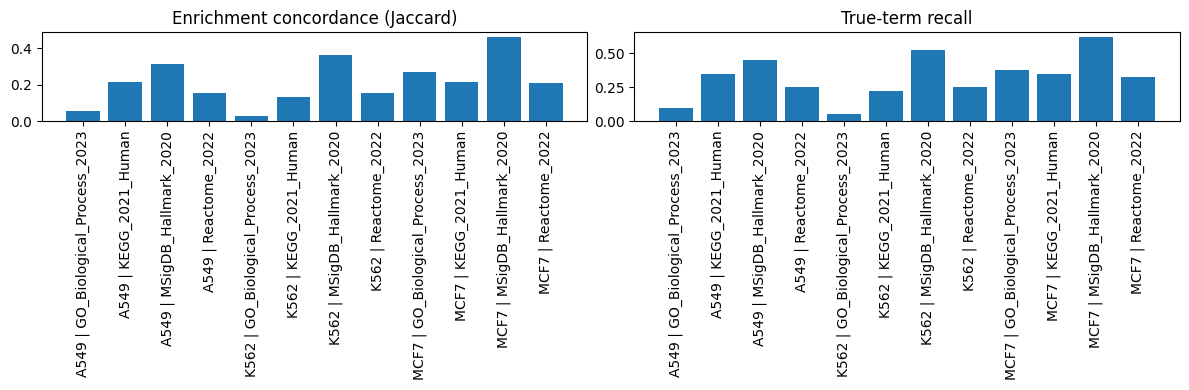

In [52]:
plot_df=summary.copy()
plot_df["cell_library"]=plot_df["cell_type"]+" | "+plot_df["library"]

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(plot_df["cell_library"], plot_df["jaccard_top_terms"])
axes[0].set_title("Enrichment concordance (Jaccard)")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(plot_df["cell_library"], plot_df["true_term_recall"])
axes[1].set_title("True-term recall")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
fig.savefig(f"{OUT_DIR}/figure_enrichment_concordance.png", dpi=220)
plt.show()

## Interpretation
- higher `jaccard_top_terms` = predicted and true top enriched terms overlap more
- higher `true_term_recall` = model recovers a larger fraction of true enriched terms
- use this notebook as **biology strengthening**, not as the only biology metric
